In [2]:
##Load LPS adata

import anndata as ad

adata_lps = ad.read_h5ad("/Users/pdevant/DE_Mac_LPS_anndata.h5ad")
adata_lps



import sys
print(sys.executable)

import anndata, scanpy
print("anndata", anndata.__version__)
print("scanpy", scanpy.__version__)


# Creat Z-score layer

adata_lps.layers["zscore"] = (
    adata_lps.layers["log_fc"] / adata_lps.layers["lfcSE"]
)

adata_lps.layers.keys()

/opt/miniconda3/envs/perturbseq311/bin/python
anndata 0.12.6
scanpy 1.11.5


/var/folders/9l/dyp50m2d6s30t17769kjdmt00000gr/T/ipykernel_44526/1696939011.py:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata", anndata.__version__)
/var/folders/9l/dyp50m2d6s30t17769kjdmt00000gr/T/ipykernel_44526/1696939011.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", scanpy.__version__)


KeysView(Layers with keys: adj_p_value, baseMean, lfcSE, log_fc, p_value, zscore)

In [6]:
# 1) Load Ctrl DE object
adata_ctrl = ad.read_h5ad("/Users/pdevant/DE_Mac_Ctrl_anndata.h5ad")
adata_ctrl
# 2) Make zscore layer
if "zscore" not in adata_ctrl.layers:
    adata_ctrl.layers["zscore"] = adata_ctrl.layers["log_fc"] / adata_ctrl.layers["lfcSE"]

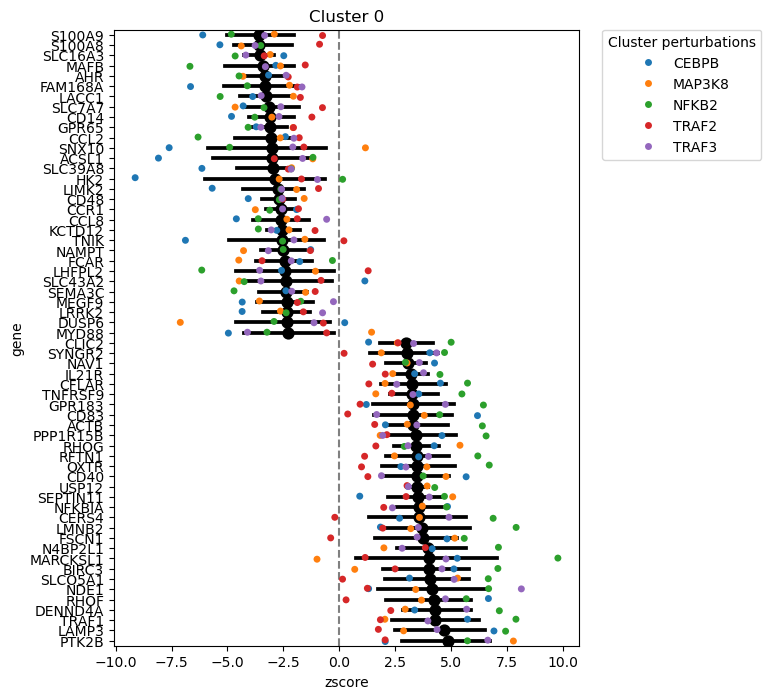

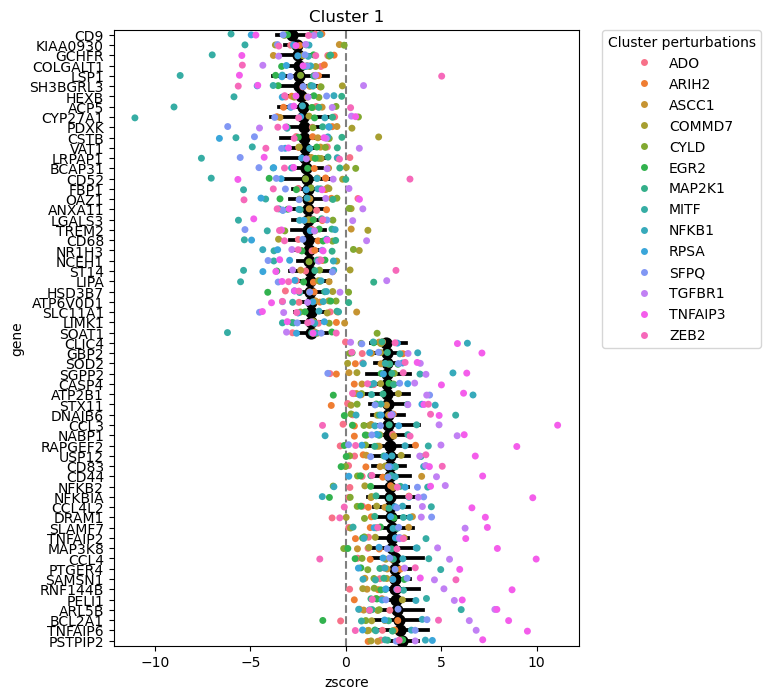

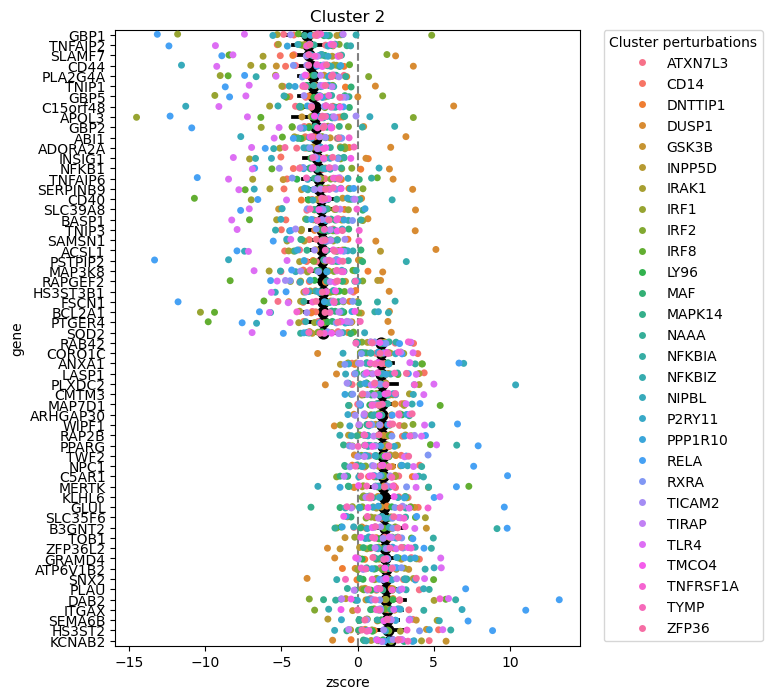

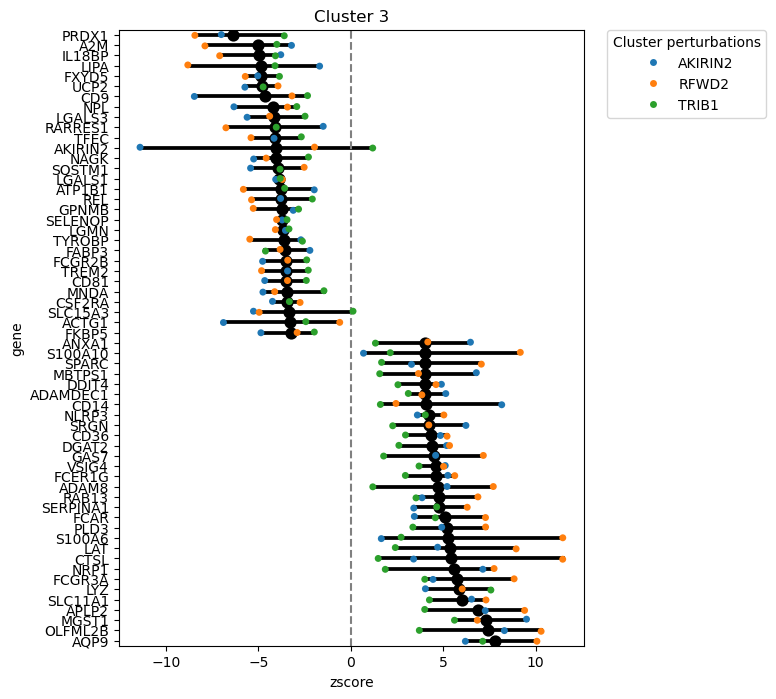

In [9]:
## Rerun GSEA analysis but with cluster assigments from HDBSCAN that Ron ran for use (see in macs_cluster.ipynb)

import os
import pandas as pd
import gseapy as gp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
#Define clusters

cluster_map = {
    # Cluster 0
    "CEBPB":0, "MAP3K8":0, "NFKB2":0, "TRAF2":0, "TRAF3":0,

    # Cluster 1
    "ADO":1, "ARIH2":1, "ASCC1":1, "COMMD7":1, "CYLD":1, "EGR2":1,
    "MAP2K1":1, "MITF":1, "NFKB1":1, "RPSA":1, "SFPQ":1,
    "TGFBR1":1, "TNFAIP3":1, "ZEB2":1,

    # Cluster 2
    "ATXN7L3":2, "CD14":2, "DNTTIP1":2, "DUSP1":2, "GSK3B":2,
    "INPP5D":2, "IRAK1":2, "IRF1":2, "IRF2":2, "IRF8":2,
    "LY96":2, "MAF":2, "MAPK14":2, "NAAA":2, "NFKBIA":2,
    "NFKBIZ":2, "NIPBL":2, "P2RY11":2, "PPP1R10":2, "RELA":2,
    "RXRA":2, "TICAM2":2, "TIRAP":2, "TLR4":2, "TMCO4":2,
    "TNFRSF1A":2, "TYMP":2, "ZFP36":2,

    # Cluster 3
    "AKIRIN2":3, "RFWD2":3, "TRIB1":3
}

cluster_series = pd.Series(cluster_map)


zmat = pd.DataFrame(
        adata_lps.layers["zscore"],
        index=adata_lps.obs["contrast"].astype(str),
        columns=adata_lps.var_names
    ).T

cluster_series = cluster_series[cluster_series.index.isin(zmat.columns)]
zmat = zmat[cluster_series.index]


all_downstream_rankings = []
n_top = 30

for cl in sorted(cluster_series.unique()):

    # get z-scores for cluster members
    zmat_cl = zmat.loc[:, cluster_series == cl]
    zmat_cl = zmat_cl.fillna(0)

    sorted_meanz_genes = zmat_cl.mean(axis=1).sort_values()

    downstream_ranking = pd.DataFrame({
        "mean_z": sorted_meanz_genes,
        "rank_neg": sorted_meanz_genes.rank(method="max", ascending=False),
        "rank_pos": sorted_meanz_genes.rank(method="max")
    })

    downstream_ranking["cluster"] = cl
    all_downstream_rankings.append(downstream_ranking)

    # Top genes
    top_up = sorted_meanz_genes.nlargest(n_top).index.tolist()
    top_down = sorted_meanz_genes.nsmallest(n_top).index.tolist()

    zmat_cl_2_plot = (
        zmat_cl
        .reset_index()
        .melt(id_vars="index", value_name="zscore", var_name="perturbation")
        .rename(columns={"index":"gene"})
    )

    zmat_cl_2_plot = zmat_cl_2_plot[
        zmat_cl_2_plot["gene"].isin(top_up + top_down)
    ]

    plt.figure(figsize=(6,8))

    ax = sns.stripplot(
        data=zmat_cl_2_plot,
        x="zscore",
        y="gene",
        hue="perturbation",
        order=top_down + top_up[::-1],
    )

    sns.pointplot(
        data=zmat_cl_2_plot,
        x="zscore",
        y="gene",
        order=top_down + top_up[::-1],
        linestyles="none",
        color="black",
        ax=ax
    )

    ax.axvline(0, color="grey", linestyle="--")
    plt.title(f"Cluster {cl}")
    plt.legend(
        bbox_to_anchor=(1.05,1),
        loc="upper left",
        borderaxespad=0,
        title="Cluster perturbations"
    )

    plt.show()


downstream_ranking_results = pd.concat(all_downstream_rankings)

downstream_ranking_results.reset_index() \
    .rename(columns={"index":"gene"}) \
    .to_csv("LPS_cluster_downstream_rankings_NEWclusters.csv", index=False)

In [10]:
# Clean preranked GSEA for one cluster using mean_z as ranking metric

import os
import pandas as pd
import gseapy as gp

# -----------------------------
# Choose cluster to analyze
# -----------------------------
cl = 0   # change to 0, 1, 2, or 3

# -----------------------------
# Build ranked gene vector
# -----------------------------
rnk = (
    downstream_ranking_results
    .query("cluster == @cl")
    .reset_index()
    .rename(columns={"index": "gene"})
    .loc[:, ["gene", "mean_z"]]
    .dropna()
    .drop_duplicates(subset="gene", keep="first")
    .sort_values("mean_z", ascending=False)
)

# GSEApy accepts either a 2-column dataframe or a series
rnk_for_gsea = rnk[["gene", "mean_z"]]

print(f"Cluster {cl} genes in ranking: {rnk_for_gsea.shape[0]}")
display(rnk_for_gsea.head())

# -----------------------------
# Output directory
# -----------------------------
outdir = f"gsea_cluster_{cl}"
os.makedirs(outdir, exist_ok=True)

# -----------------------------
# Gene set collections
# -----------------------------
gene_sets = [
    "MSigDB_Hallmark_2020",
    "Reactome_2022",
    "GO_Biological_Process_2023",
]

# -----------------------------
# Run preranked GSEA
# -----------------------------
all_res = []

for gs in gene_sets:
    print(f"\nRunning GSEA for {gs} ...")

    pre_res = gp.prerank(
        rnk=rnk_for_gsea,
        gene_sets=gs,
        min_size=15,
        max_size=500,
        permutation_num=2000,
        seed=1,
        outdir=os.path.join(outdir, gs.replace(" ", "_")),
        verbose=True,
    )

    res = pre_res.res2d.copy()
    res["gene_set_db"] = gs
    all_res.append(res)

gsea_results = pd.concat(all_res, ignore_index=False)

# -----------------------------
# Save combined table
# -----------------------------
gsea_results.to_csv(
    os.path.join(outdir, f"cluster_{cl}_gsea_prerank_results.csv"),
    index=True
)

# -----------------------------
# Show top terms by FDR
# -----------------------------
def show_top(res_df, db, n=15):
    df = res_df[res_df["gene_set_db"] == db].copy()
    df = df.sort_values("FDR q-val", ascending=True)
    cols = [c for c in ["Term", "NES", "NOM p-val", "FDR q-val", "Lead_genes"] if c in df.columns]
    print(f"\n=== TOP terms: {db} ===")
    display(df[cols].head(n))

for db in gene_sets:
    show_top(gsea_results, db, n=15)

# -----------------------------
# Show strongest positive and negative NES
# -----------------------------
def show_extremes(res_df, db, n=10):
    df = res_df[res_df["gene_set_db"] == db].copy()

    print(f"\n=== Strongest +NES: {db} ===")
    display(df.sort_values("NES", ascending=False)[["Term", "NES", "FDR q-val"]].head(n))

    print(f"\n=== Strongest -NES: {db} ===")
    display(df.sort_values("NES", ascending=True)[["Term", "NES", "FDR q-val"]].head(n))

for db in gene_sets:
    show_extremes(gsea_results, db, n=10)

Cluster 0 genes in ranking: 12403


,gene,mean_z
12402,PTK2B,4.845759
12401,LAMP3,4.663602
12400,TRAF1,4.288360
12399,DENND4A,4.288203
12398,RHOF,4.208755


2026-04-01 10:31:13,477 [WARNING] Duplicated values found in preranked stats: 8.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:31:13,477 [INFO] Parsing data files for GSEA.............................
2026-04-01 10:31:13,488 [INFO] Enrichr library gene sets already downloaded in: /Users/pdevant/.cache/gseapy, use local file
2026-04-01 10:31:13,494 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-01 10:31:13,495 [INFO] 0050 gene_sets used for further statistical testing.....
2026-04-01 10:31:13,495 [INFO] Start to run GSEA...Might take a while..................



Running GSEA for MSigDB_Hallmark_2020 ...


2026-04-01 10:31:19,418 [INFO] Congratulations. GSEApy runs successfully................

2026-04-01 10:31:19,437 [WARNING] Duplicated values found in preranked stats: 8.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:31:19,438 [INFO] Parsing data files for GSEA.............................
2026-04-01 10:31:19,444 [INFO] Enrichr library gene sets already downloaded in: /Users/pdevant/.cache/gseapy, use local file
2026-04-01 10:31:19,464 [INFO] 0816 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-01 10:31:19,464 [INFO] 1002 gene_sets used for further statistical testing.....
2026-04-01 10:31:19,465 [INFO] Start to run GSEA...Might take a while..................


...

,Term,NES,FDR q-val
2,Amine Ligand-Binding Receptors R-HSA-375280,-1.866827,0.148647
4,Scavenging By Class A Receptors R-HSA-3000480,-1.839241,0.103793
5,Antimicrobial Peptides R-HSA-6803157,-1.827148,0.084652
7,IRAK4 Deficiency (TLR2/4) R-HSA-5603041,-1.791811,0.104768
8,Cell Recruitment (Pro-Inflammatory Response) R...,-1.77019,0.11259
9,Regulation Of TLR By Endogenous Ligand R-HSA-5...,-1.742262,0.133118
10,Basigin Interactions R-HSA-210991,-1.741216,0.115277
15,Beta Defensins R-HSA-1461957,-1.603424,0.446969
17,Cholesterol Biosynthesis R-HSA-191273,-1.597881,0.421816
19,"Transport Of Bile Salts And Organic Acids, Met...",-1.583711,0.428562



=== Strongest +NES: GO_Biological_Process_2023 ===


,Term,NES,FDR q-val
1,Regulation Of Axonogenesis (GO:0050770),1.886404,0.15438
2,Heterophilic Cell-Cell Adhesion Via Plasma Mem...,1.862946,0.130877
4,Homophilic Cell Adhesion Via Plasma Membrane A...,1.849156,0.109187
5,Negative Regulation Of Endothelial Cell Apopto...,1.827908,0.121228
6,Retina Homeostasis (GO:0001895),1.822502,0.107472
8,Lymphocyte Proliferation (GO:0046651),1.797907,0.138216
9,Positive Regulation Of Axonogenesis (GO:0050772),1.761054,0.209303
10,Tumor Necrosis Factor-Mediated Signaling Pathw...,1.759106,0.189078
14,Cell-Cell Adhesion Mediated By Cadherin (GO:00...,1.747069,0.20463
15,Cell Junction Assembly (GO:0034329),1.741549,0.200941



=== Strongest -NES: GO_Biological_Process_2023 ===


,Term,NES,FDR q-val
0,Regulation Of Postsynaptic Membrane Potential ...,-2.016815,0.018776
3,Defense Response To Fungus (GO:0050832),-1.853994,0.222524
7,Positive Regulation Of Vascular Endothelial Gr...,-1.806972,0.301096
11,Metanephros Development (GO:0001656),-1.754733,0.470801
12,Sterol Transport (GO:0015918),-1.753096,0.385877
13,Cellular Response To cAMP (GO:0071320),-1.750064,0.333489
17,Fatty Acid Transport (GO:0015908),-1.736695,0.339349
19,"G Protein-Coupled Receptor Signaling Pathway, ...",-1.730428,0.319069
22,Synaptic Vesicle Cycle (GO:0099504),-1.717708,0.33098
23,Sensory Organ Development (GO:0007423),-1.717475,0.298897


In [11]:
#Run GSEA for all clusters

all_cluster_gsea = {}

for cl in sorted(downstream_ranking_results["cluster"].unique()):
    print(f"\n##############################")
    print(f"Running cluster {cl}")
    print(f"##############################")

    rnk = (
        downstream_ranking_results
        .query("cluster == @cl")
        .reset_index()
        .rename(columns={"index": "gene"})
        .loc[:, ["gene", "mean_z"]]
        .dropna()
        .drop_duplicates(subset="gene", keep="first")
        .sort_values("mean_z", ascending=False)
    )

    rnk_for_gsea = rnk[["gene", "mean_z"]]

    outdir = f"gsea_cluster_{cl}"
    os.makedirs(outdir, exist_ok=True)

    all_res = []
    for gs in ["MSigDB_Hallmark_2020", "Reactome_2022", "GO_Biological_Process_2023"]:
        pre_res = gp.prerank(
            rnk=rnk_for_gsea,
            gene_sets=gs,
            min_size=15,
            max_size=500,
            permutation_num=2000,
            seed=1,
            outdir=os.path.join(outdir, gs.replace(" ", "_")),
            verbose=False,
        )
        res = pre_res.res2d.copy()
        res["gene_set_db"] = gs
        all_res.append(res)

    gsea_results = pd.concat(all_res, ignore_index=False)
    gsea_results.to_csv(
        os.path.join(outdir, f"cluster_{cl}_gsea_prerank_results.csv"),
        index=True
    )
    all_cluster_gsea[cl] = gsea_results

2026-04-01 10:32:37,366 [WARNING] Duplicated values found in preranked stats: 8.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



##############################
Running cluster 0
##############################


2026-04-01 10:32:43,846 [WARNING] Duplicated values found in preranked stats: 8.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:33:06,094 [WARNING] Duplicated values found in preranked stats: 8.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:33:43,661 [WARNING] Duplicated values found in preranked stats: 5.94% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



##############################
Running cluster 1
##############################


2026-04-01 10:33:50,048 [WARNING] Duplicated values found in preranked stats: 5.94% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:34:12,940 [WARNING] Duplicated values found in preranked stats: 5.94% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:34:52,810 [WARNING] Duplicated values found in preranked stats: 4.42% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



##############################
Running cluster 2
##############################


2026-04-01 10:34:59,135 [WARNING] Duplicated values found in preranked stats: 4.42% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:35:22,175 [WARNING] Duplicated values found in preranked stats: 4.42% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:36:01,988 [WARNING] Duplicated values found in preranked stats: 9.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



##############################
Running cluster 3
##############################


2026-04-01 10:36:05,986 [WARNING] Duplicated values found in preranked stats: 9.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-01 10:36:28,334 [WARNING] Duplicated values found in preranked stats: 9.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [12]:
##Define plotting function of GO terms

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

sns.set_style("white")
sns.set_context("paper")

def plot_top_gsea_terms(
    gsea_results,
    cluster_label,
    gene_set_db="GO_Biological_Process_2023",
    n_top=5,
    nes_col="NES",
    term_col="Term",
    figsize=(10, 5.5),
    wrap_width=42,
    save_pdf=None,
):
    df = gsea_results.copy()
    df = df[df["gene_set_db"] == gene_set_db].copy()

    df[nes_col] = pd.to_numeric(df[nes_col], errors="coerce")
    df = df.dropna(subset=[nes_col, term_col]).copy()

    # top positive and negative NES
    df_pos = df[df[nes_col] > 0].sort_values(nes_col, ascending=False).head(n_top).copy()
    df_neg = df[df[nes_col] < 0].sort_values(nes_col, ascending=True).head(n_top).copy()

    plot_df = pd.concat([df_neg, df_pos], axis=0).copy()

    if plot_df.empty:
        print(f"No terms to plot for cluster {cluster_label}, {gene_set_db}")
        return

    # Clean up GO labels
    plot_df[term_col] = (
        plot_df[term_col]
        .astype(str)
        .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
        .apply(lambda x: textwrap.fill(x, width=wrap_width))
    )

    plot_df["direction"] = np.where(plot_df[nes_col] > 0, "Positive NES", "Negative NES")

    # Preserve order
    plot_df[term_col] = pd.Categorical(
        plot_df[term_col],
        categories=plot_df[term_col].tolist(),
        ordered=True
    )

    # Colors without needing a legend
    bar_colors = plot_df["direction"].map({
        "Positive NES": "#d95f02",
        "Negative NES": "#1f78b4"
    })

    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(
        y=np.arange(len(plot_df)),
        width=plot_df[nes_col],
        color=bar_colors,
        edgecolor="none"
    )

    ax.set_yticks(np.arange(len(plot_df)))
    ax.set_yticklabels(plot_df[term_col])

    # symmetric x-axis around 0
    xmax = np.ceil(np.max(np.abs(plot_df[nes_col])) * 10) / 10
    ax.set_xlim(-xmax * 1.1, xmax * 1.1)

    ax.axvline(0, color="black", linewidth=1)

    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_ylabel("")
    ax.set_title(f"Cluster {cluster_label} — top GSEA terms\n{gene_set_db}")

    ax.tick_params(axis="x", bottom=True, length=3, width=0.8, direction="out")
    ax.tick_params(axis="y", length=0)

    sns.despine(ax=ax, left=True, bottom=False)
    plt.tight_layout()

    if save_pdf is not None:
        plt.savefig(save_pdf, bbox_inches="tight")

    plt.show()

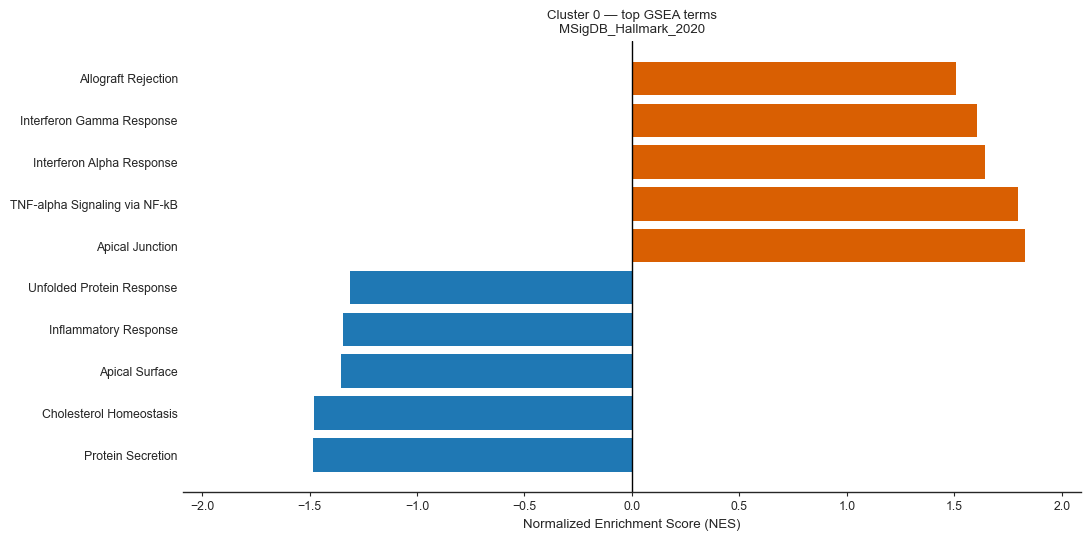

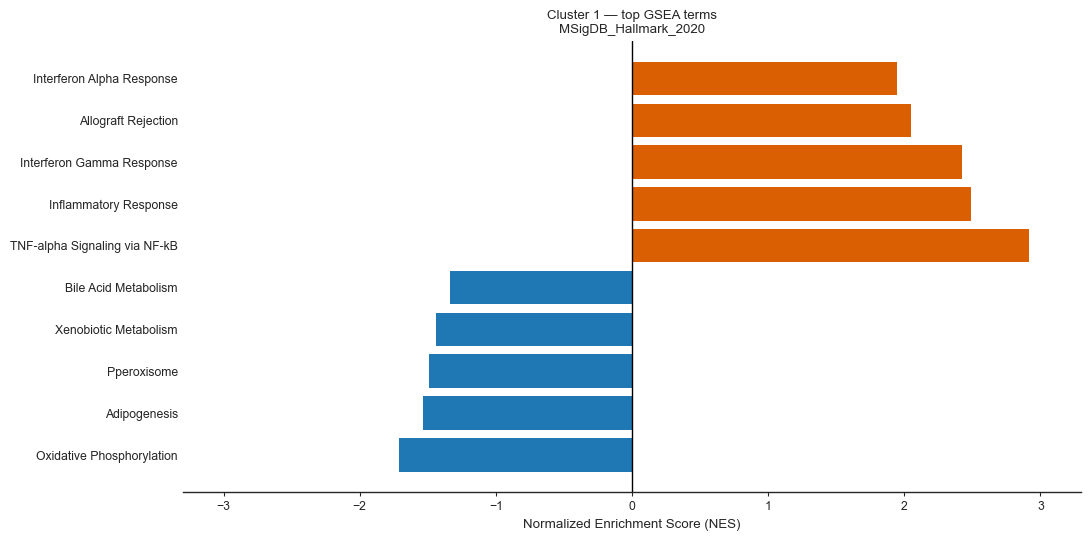

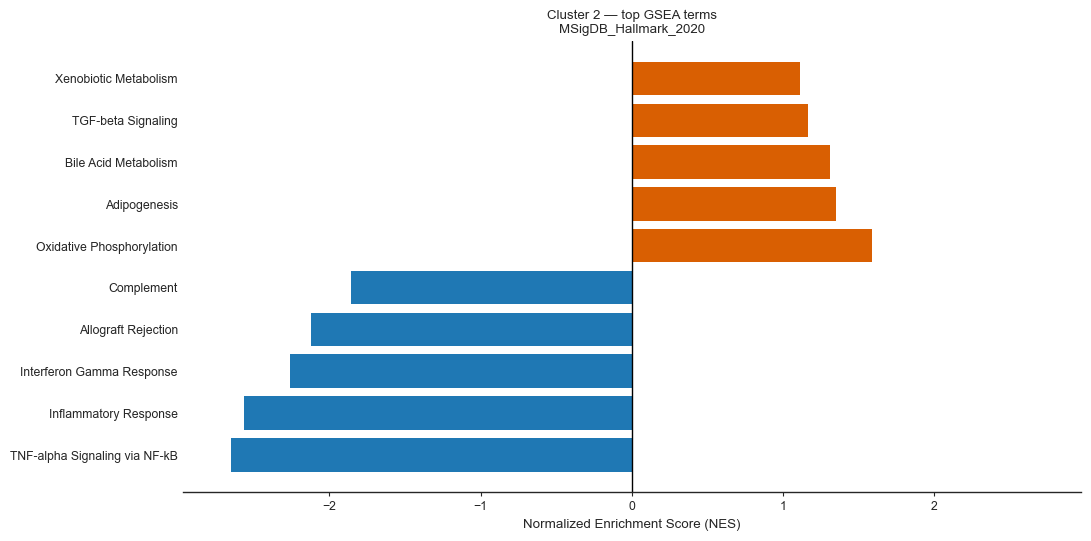

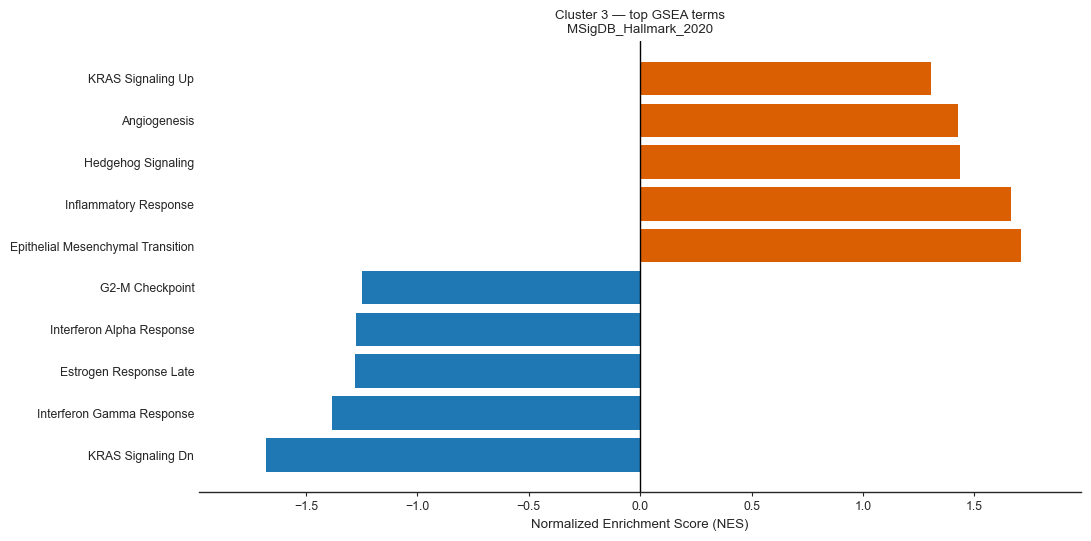

In [13]:
#Plot Top terms from Hallmark geneset for each cluster

plot_top_gsea_terms(
    all_cluster_gsea[0],
    cluster_label=0,
    gene_set_db="MSigDB_Hallmark_2020",
    n_top=5,
    figsize=(11, 5.5),
    save_pdf="cluster0_top_gsea_GO_clean.pdf"
)

plot_top_gsea_terms(
    all_cluster_gsea[1],
    cluster_label=1,
    gene_set_db="MSigDB_Hallmark_2020",
    n_top=5,
    figsize=(11, 5.5),
    save_pdf="cluster1_top_gsea_GO_clean.pdf"
)

plot_top_gsea_terms(
    all_cluster_gsea[2],
    cluster_label=2,
    gene_set_db="MSigDB_Hallmark_2020",
    n_top=5,
    figsize=(11, 5.5),
    save_pdf="cluster2_top_gsea_GO_clean.pdf"
)

plot_top_gsea_terms(
    all_cluster_gsea[3],
    cluster_label=3,
    gene_set_db="MSigDB_Hallmark_2020",
    n_top=5,
    figsize=(11, 5.5),
    save_pdf="cluster3_top_gsea_GO_clean.pdf"
)

Perturbations found in Ctrl dataset: 50
0     5
1    14
2    28
3     3
Name: count, dtype: int64


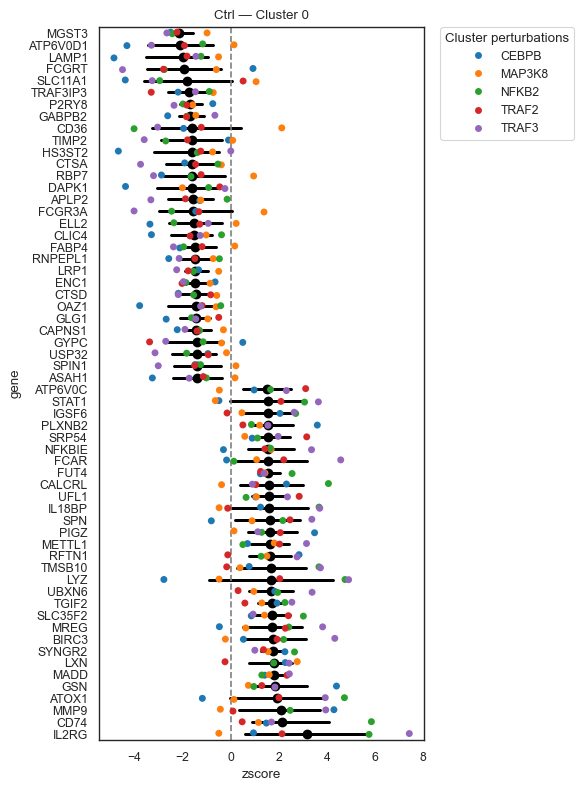

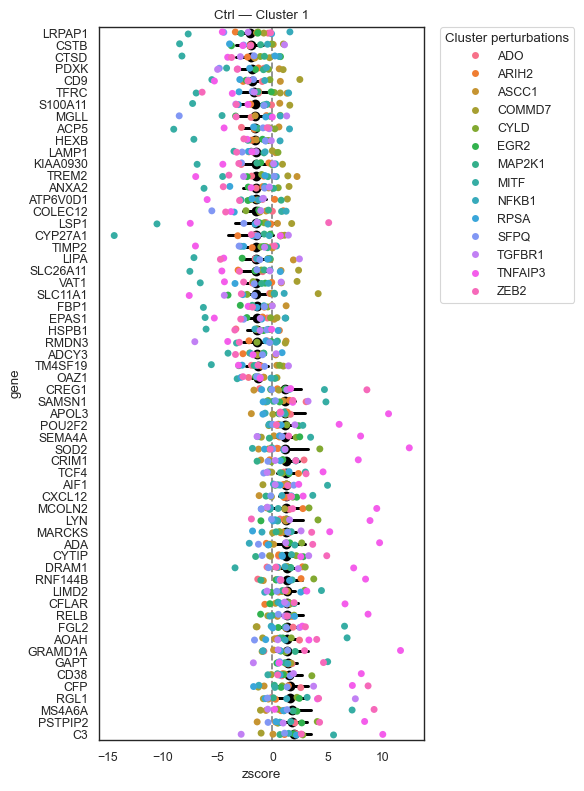

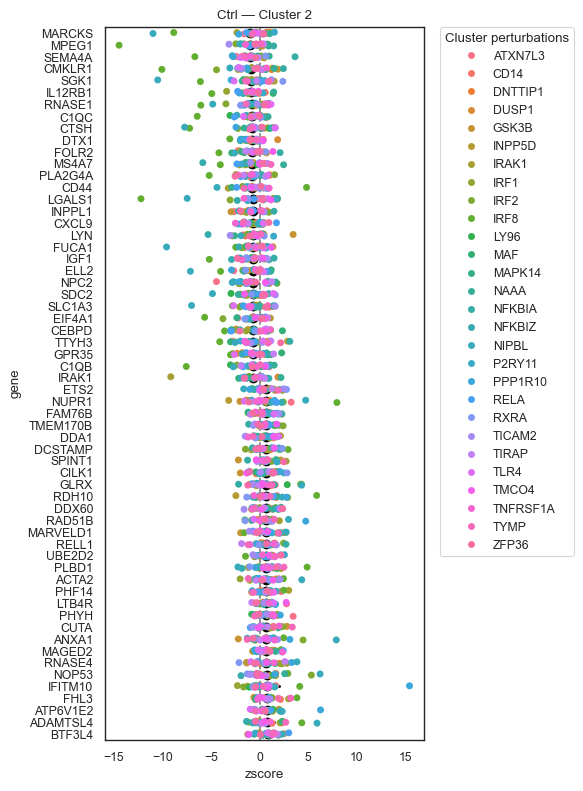

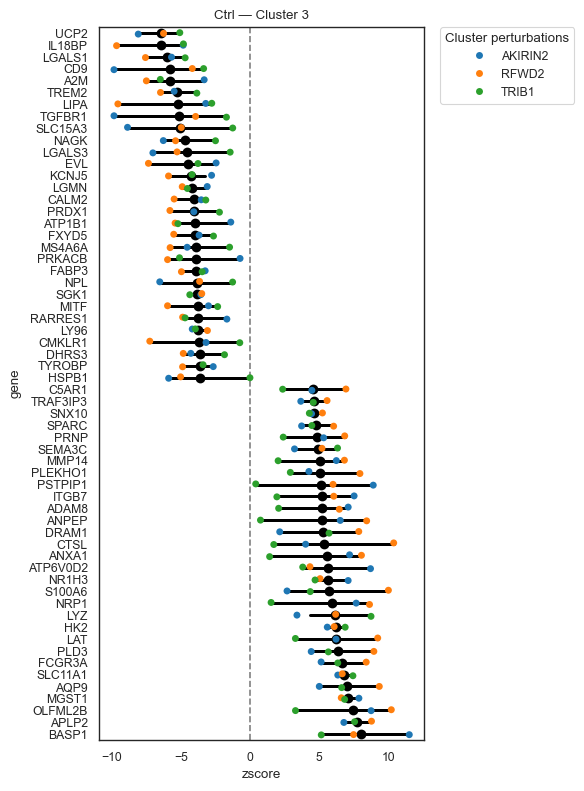

Saved: CTRL_cluster_downstream_rankings_NEWclusters.csv


In [14]:
##Generate ranked gene expression means for all clusters in control conditions --> Same cluster genes as in LPS analysis

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
sns.set_context("paper")

# -----------------------------
# Define clusters
# -----------------------------
cluster_map = {
    # Cluster 0
    "CEBPB": 0, "MAP3K8": 0, "NFKB2": 0, "TRAF2": 0, "TRAF3": 0,

    # Cluster 1
    "ADO": 1, "ARIH2": 1, "ASCC1": 1, "COMMD7": 1, "CYLD": 1, "EGR2": 1,
    "MAP2K1": 1, "MITF": 1, "NFKB1": 1, "RPSA": 1, "SFPQ": 1,
    "TGFBR1": 1, "TNFAIP3": 1, "ZEB2": 1,

    # Cluster 2
    "ATXN7L3": 2, "CD14": 2, "DNTTIP1": 2, "DUSP1": 2, "GSK3B": 2,
    "INPP5D": 2, "IRAK1": 2, "IRF1": 2, "IRF2": 2, "IRF8": 2,
    "LY96": 2, "MAF": 2, "MAPK14": 2, "NAAA": 2, "NFKBIA": 2,
    "NFKBIZ": 2, "NIPBL": 2, "P2RY11": 2, "PPP1R10": 2, "RELA": 2,
    "RXRA": 2, "TICAM2": 2, "TIRAP": 2, "TLR4": 2, "TMCO4": 2,
    "TNFRSF1A": 2, "TYMP": 2, "ZFP36": 2,

    # Cluster 3
    "AKIRIN2": 3, "RFWD2": 3, "TRIB1": 3
}

cluster_series = pd.Series(cluster_map)

# -----------------------------
# Build z-score matrix from CTRL dataset
# rows = genes, columns = perturbations
# -----------------------------
zmat = pd.DataFrame(
    adata_ctrl.layers["zscore"],
    index=adata_ctrl.obs["contrast"].astype(str),
    columns=adata_ctrl.var_names
).T

# Keep only perturbations present in both the cluster map and the Ctrl dataset
cluster_series = cluster_series[cluster_series.index.isin(zmat.columns)]
zmat = zmat[cluster_series.index]

print("Perturbations found in Ctrl dataset:", len(cluster_series))
print(cluster_series.value_counts().sort_index())

# -----------------------------
# Run downstream ranking analysis
# -----------------------------
all_downstream_rankings = []
n_top = 30

for cl in sorted(cluster_series.unique()):
    zmat_cl = zmat.loc[:, cluster_series == cl].copy()
    zmat_cl = zmat_cl.fillna(0)

    sorted_meanz_genes = zmat_cl.mean(axis=1).sort_values()

    downstream_ranking = pd.DataFrame({
        "mean_z": sorted_meanz_genes,
        "rank_neg": sorted_meanz_genes.rank(method="max", ascending=False),
        "rank_pos": sorted_meanz_genes.rank(method="max")
    })
    downstream_ranking["cluster"] = cl
    all_downstream_rankings.append(downstream_ranking)

    # top genes for plotting
    top_up = sorted_meanz_genes.nlargest(n_top).index.tolist()
    top_down = sorted_meanz_genes.nsmallest(n_top).index.tolist()

    zmat_cl_2_plot = (
        zmat_cl
        .reset_index()
        .melt(id_vars="index", value_name="zscore", var_name="perturbation")
        .rename(columns={"index": "gene"})
    )

    zmat_cl_2_plot = zmat_cl_2_plot[
        zmat_cl_2_plot["gene"].isin(top_up + top_down)
    ]

    plt.figure(figsize=(6, 8))
    ax = sns.stripplot(
        data=zmat_cl_2_plot,
        x="zscore",
        y="gene",
        hue="perturbation",
        order=top_down + top_up[::-1],
    )

    sns.pointplot(
        data=zmat_cl_2_plot,
        x="zscore",
        y="gene",
        order=top_down + top_up[::-1],
        linestyles="none",
        color="black",
        ax=ax
    )

    ax.axvline(0, color="grey", linestyle="--")
    plt.title(f"Ctrl — Cluster {cl}")
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0,
        title="Cluster perturbations"
    )
    plt.tight_layout()
    plt.show()

# -----------------------------
# Save ranked results
# -----------------------------
downstream_ranking_results_ctrl = pd.concat(all_downstream_rankings)

downstream_ranking_results_ctrl.reset_index() \
    .rename(columns={"index": "gene"}) \
    .to_csv("CTRL_cluster_downstream_rankings_NEWclusters.csv", index=False)

print("Saved: CTRL_cluster_downstream_rankings_NEWclusters.csv")